In [1]:
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/groceries.csv"
df = pd.read_csv(file_path)
df

,citrus fruit,semi-finished bread,margarine,ready soups,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,sausage,chicken,beef,hamburger meat,citrus fruit,grapes,root vegetables,whole milk,butter,whipped/sour cream,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9830,cooking chocolate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9831,chicken,citrus fruit,other vegetables,butter,yogurt,frozen dessert,domestic eggs,rolls/buns,rum,cling film/bags,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9832,semi-finished bread,bottled water,soda,bottled beer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
transactions

[['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['pot plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter milk', 'pastry'],
 ['whole milk'],
 ['tropical fruit',
  'cream cheese ',


In [6]:
# !pip install prefixspan
from prefixspan import PrefixSpan

In [33]:
ps = PrefixSpan(transactions)

patterns = ps.topk(200)
filtered_patterns = [(support, seq) for support, seq in patterns if 3 <= len(seq) <= 4]

for i, (support, seq) in enumerate(filtered_patterns[:10], start=1):
    print(f"Pattern: {seq}, Support: {support}")

Pattern: ['root vegetables', 'other vegetables', 'whole milk'], Support: 228
Pattern: ['other vegetables', 'whole milk', 'yogurt'], Support: 219
Pattern: ['other vegetables', 'whole milk', 'rolls/buns'], Support: 176
Pattern: ['tropical fruit', 'other vegetables', 'whole milk'], Support: 168
Pattern: ['whole milk', 'yogurt', 'rolls/buns'], Support: 153
Pattern: ['tropical fruit', 'whole milk', 'yogurt'], Support: 149
Pattern: ['other vegetables', 'whole milk', 'whipped/sour cream'], Support: 144
Pattern: ['root vegetables', 'whole milk', 'yogurt'], Support: 143
Pattern: ['other vegetables', 'whole milk', 'soda'], Support: 137


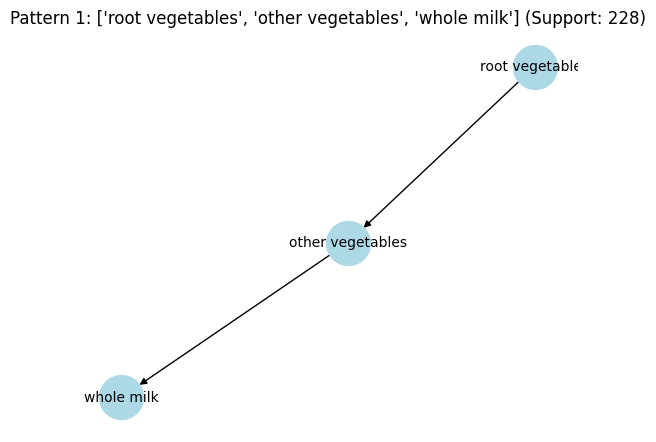

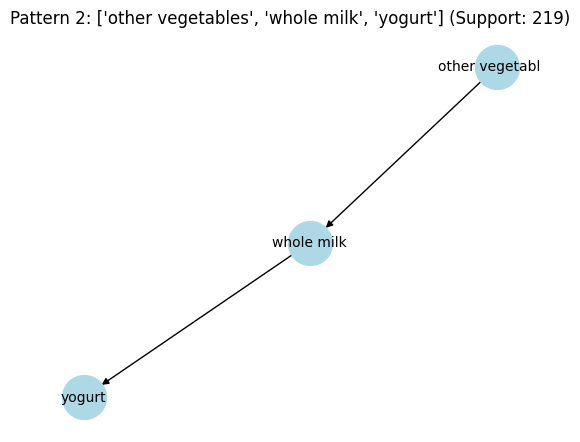

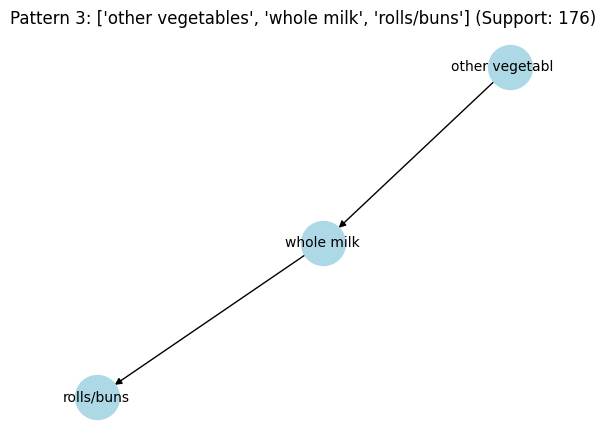

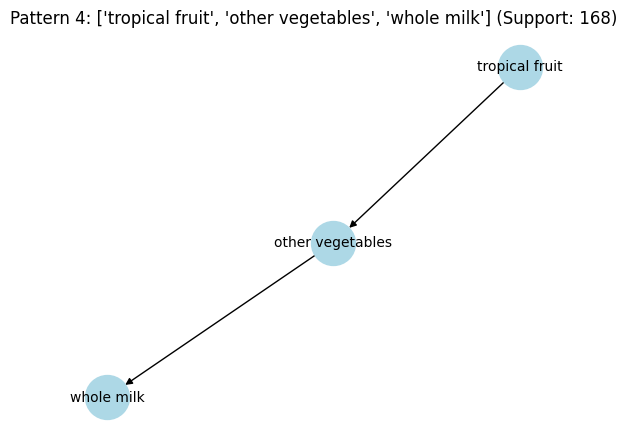

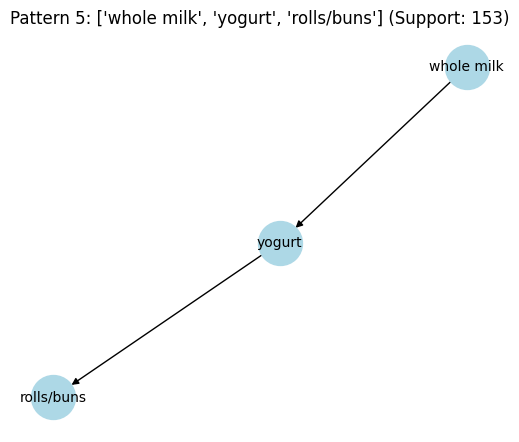

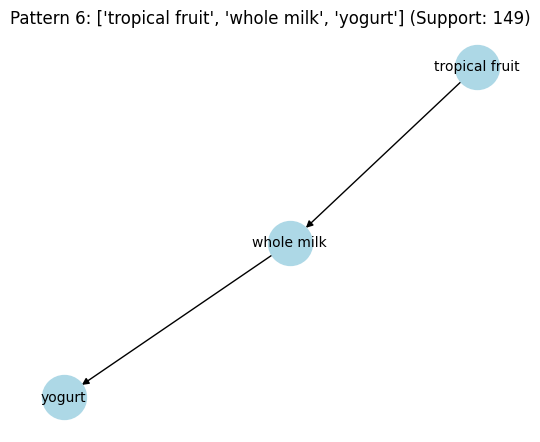

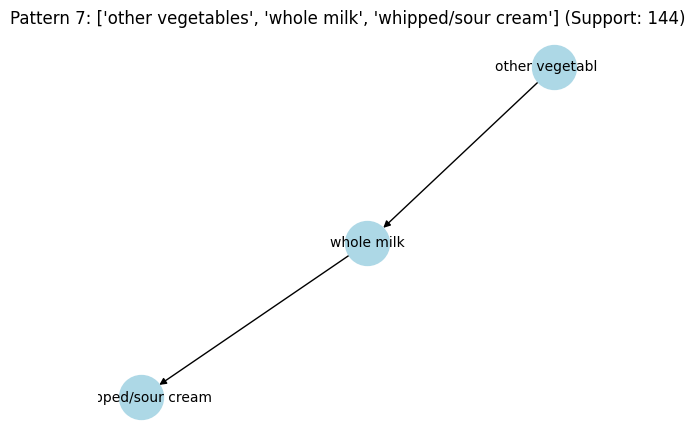

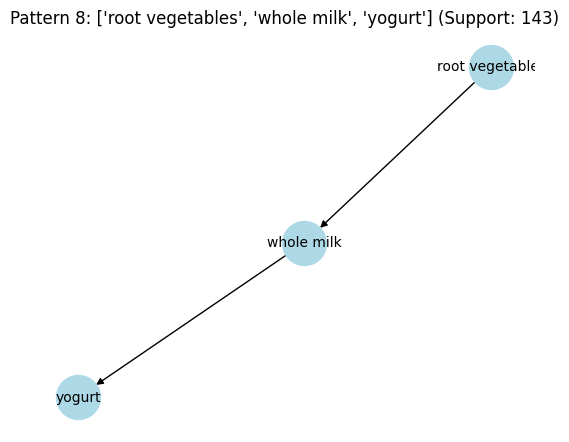

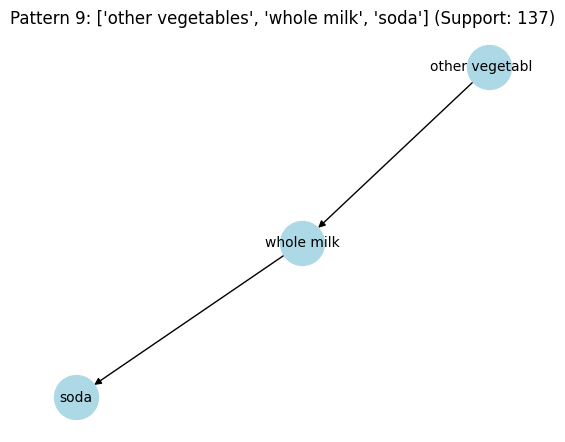

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

for idx, (support, seq) in enumerate(filtered_patterns[:10], start=1):
    G = nx.DiGraph()

    for i in range(len(seq) - 1):
        G.add_edge(seq[i], seq[i + 1])

    plt.figure(figsize=(5, 4))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1000, font_size=10, arrows=True)
    plt.title(f"Pattern {idx}: {seq} (Support: {support})")
    plt.show()

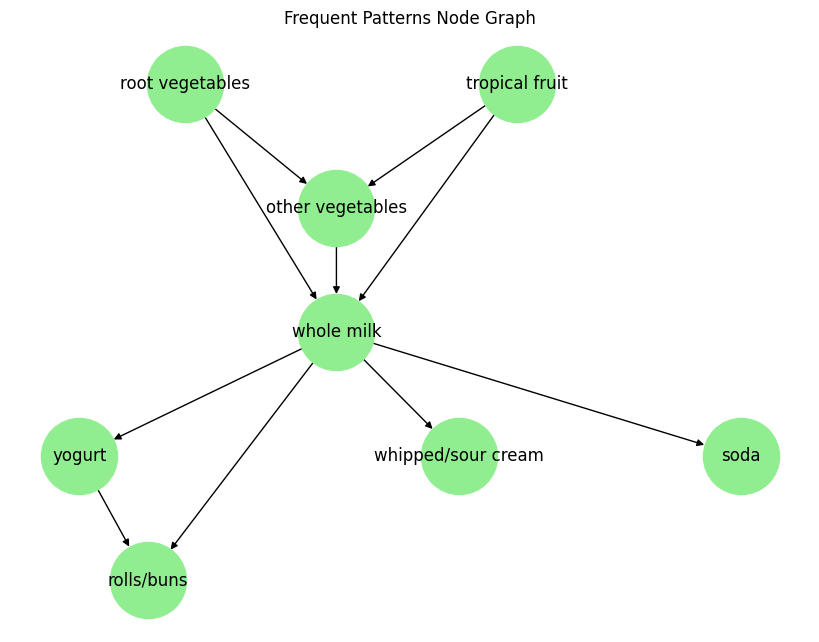

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

patterns = filtered_patterns[:10]

G = nx.DiGraph()

for support, seq in filtered_patterns:
    for i in range(len(seq) - 1):
        G.add_edge(seq[i], seq[i + 1])

plt.figure(figsize=(8, 6))
pos = nx.nx_pydot.graphviz_layout(G, prog = "dot")
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=3000, font_size=12, arrows=True)
plt.title("Frequent Patterns Node Graph")
plt.show()